# COSC2669 Individual Task 2: Part 2, Deliberation on Task 1 Analysis
**Arya Khamkar (s4152566)**, RMIT University

Reflects on the Task 1 Part 1 analysis (`../s4152566-task1-analysis.ipynb`):
- **Dataset A:** NBA attendance (30,546 games), regression. Models: SVR, XGBoost
- **Dataset B:** Telecom churn (3,333 customers), classification. Models: SVC, XGBoost

Seed: `RANDOM_STATE = 7` (same as Task 1)

## 0. Setup
Install packages into this kernel, then imports, constants, and data paths (`data/dataset.csv`, `data/telecom_churn.csv`).

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (TimeSeriesSplit, StratifiedKFold,
                                      cross_validate, cross_val_predict,
                                      learning_curve, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, SVC
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             precision_score, recall_score, f1_score)
from xgboost import XGBRegressor, XGBClassifier

RANDOM_STATE = 7
SUBSAMPLE_N = 5000

## 1. Data loading and preprocessing (same as Task 1)
The preprocessing must match Task 1 exactly. Copy it from the Task 1 notebook and note any differences.

### 1.1 Attendance

In [3]:
nba = pd.read_csv("data/dataset.csv")
nba["Time"] = pd.to_datetime(nba["Time"], format="ISO8601")

# Sort the data by date
nba = nba.sort_values("Time").reset_index(drop=True)

# Remove Capacity because it causes leakage
df = nba.drop(columns=["Capacity"])

# Keep these columns for the fairness part later
meta_att = df[["Time", "H Pop", "Attendance"]].copy()

train_mask = df["Time"] < "2015-01-01"

# Time is not used as a model feature
df = df.drop(columns=["Time"])

# Attendance is the value we want to predict
y = df.pop("Attendance")

# Convert categorical columns into numbers
cat_cols = ['Home', 'Visitor', 'Playoffs?', 'Day of Week', 'Month', 'Rivalry?']
X = pd.get_dummies(df, columns=cat_cols, drop_first=True).astype(float)

# Use all rows for CV
X_cv = X.copy()
y_cv = y.copy()
meta_cv = meta_att.copy()

# Reset the indexes so they match
X_cv = X_cv.reset_index(drop=True)
y_cv = y_cv.reset_index(drop=True)
meta_cv = meta_cv.reset_index(drop=True)

print(X.shape, X_cv.shape, nba["Time"].is_monotonic_increasing)

(30546, 81) (30546, 81) True


### 1.2 Churn

In [4]:
# Load the churn data
churn = pd.read_csv("data/telecom_churn.csv")

# Churn is the value we want to predict
yc = churn.pop("Churn")

# Keep the remaining columns as input features
Xc = churn

# Keep these columns for the fairness checks later
meta_churn = Xc[["DataPlan", "CustServCalls", "AccountWeeks"]].copy()

print(Xc.shape, yc.mean().round(3))

(3333, 10) 0.145


In [5]:
def make_svr():
    # Create the SVM regression model
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=100,
            gamma="scale",
            epsilon=100
        ))
    ])


def make_svc():
    # Create the SVM classification model
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=RANDOM_STATE
        ))
    ])


def make_xgb_reg():
    # Create the XGBoost regression model
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


def make_xgb_clf():
    # Create the XGBoost classification model
    return XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

## 2. (a) Cross-validation and sampling
**Brief:** Was the evaluation unbiased? Justify the CV and sampling choices.

### 2.1 Churn


In [6]:
# Make 10 stratified folds
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Check the folds
for k, (tr, te) in enumerate(skf.split(Xc, yc)):
    print(
        k,
        len(tr),
        len(te),
        round(yc.iloc[te].mean(), 3),
        int(yc.iloc[te].sum())
    )

# Metrics to use
scoring_c = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

cv_churn = {}

# Run cross-validation for both models
for name, make in [
    ("SVM (RBF)", make_svc),
    ("XGBoost", make_xgb_clf)
]:
    res = cross_validate(
        make(),
        Xc,
        yc,
        cv=skf,
        scoring=scoring_c,
        return_train_score=True,
        n_jobs=-1
    )

    cv_churn[name] = pd.DataFrame(res)

0 2999 334 0.147 49
1 2999 334 0.147 49
2 2999 334 0.147 49
3 3000 333 0.144 48
4 3000 333 0.144 48
5 3000 333 0.144 48
6 3000 333 0.144 48
7 3000 333 0.144 48
8 3000 333 0.144 48
9 3000 333 0.144 48


In [7]:
churn_summary = []

# Calculate the mean and standard deviation
for name, res in cv_churn.items():
    row = {"model": name}

    for metric in [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ]:
        row[f"{metric}_mean"] = res[f"test_{metric}"].mean()
        row[f"{metric}_std"] = res[f"test_{metric}"].std()

    churn_summary.append(row)

churn_summary = pd.DataFrame(churn_summary)

display(churn_summary.round(3))

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,SVM (RBF),0.917,0.009,0.860,0.067,0.518,0.065,0.643,0.049,0.890,0.027,0.767,0.043
1,XGBoost,0.932,0.011,0.847,0.042,0.650,0.087,0.732,0.058,0.898,0.039,0.802,0.064


### 2.2 Attendance

In [8]:
# Make 5 time-based folds
tscv = TimeSeriesSplit(n_splits=5)

# Store the results for each model
cv_attendance = {}

for name, make in [
    ("SVR (RBF)", make_svr),
    ("XGBoost", make_xgb_reg)
]:
    fold_results = []
    all_y_true = []
    all_y_pred = []
    all_rows = []

    # Run the model on each time-based fold
    for fold, (tr, te) in enumerate(tscv.split(X_cv), start=1):

        # Use the same training sample size as Task 1
        rng = np.random.RandomState(RANDOM_STATE + fold)

        if len(tr) > SUBSAMPLE_N:
            tr_use = rng.choice(tr, size=SUBSAMPLE_N, replace=False)
        else:
            tr_use = tr

        model = make()

        # Train the model
        model.fit(X_cv.iloc[tr_use], y_cv.iloc[tr_use])

        # Predict the test data
        pred = model.predict(X_cv.iloc[te])

        # Save predictions and row numbers
        all_y_true.extend(y_cv.iloc[te])
        all_y_pred.extend(pred)
        all_rows.extend(te)

        # Calculate fold metrics
        mae = mean_absolute_error(y_cv.iloc[te], pred)
        rmse = np.sqrt(mean_squared_error(y_cv.iloc[te], pred))
        r2 = r2_score(y_cv.iloc[te], pred)

        fold_results.append({
            "fold": fold,
            "train_n": len(tr_use),
            "test_n": len(te),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    cv_attendance[name] = pd.DataFrame(fold_results)
    cv_attendance[name]["model"] = name

    print(f"\n{name}")
    display(cv_attendance[name].round(3))


# Save the held-out XGBoost predictions
attendance_predictions = pd.DataFrame({
    "row": all_rows,
    "actual": all_y_true,
    "pred": all_y_pred
})

display(attendance_predictions.head())


# Show the average results for each model
attendance_summary = []

for name, res in cv_attendance.items():
    attendance_summary.append({
        "model": name,
        "MAE_mean": res["MAE"].mean(),
        "MAE_std": res["MAE"].std(),
        "RMSE_mean": res["RMSE"].mean(),
        "RMSE_std": res["RMSE"].std(),
        "R2_mean": res["R2"].mean(),
        "R2_std": res["R2"].std()
    })

attendance_summary = pd.DataFrame(attendance_summary)

display(attendance_summary.round(3))


SVR (RBF)


,fold,train_n,test_n,MAE,RMSE,R2,model
0,1,5000,5091,2012.896,2638.757,0.395,SVR (RBF)
1,2,5000,5091,1841.023,2329.476,0.279,SVR (RBF)
2,3,5000,5091,1790.866,2185.206,0.344,SVR (RBF)
3,4,5000,5091,1398.729,1877.715,0.396,SVR (RBF)
4,5,5000,5091,1230.459,1687.555,0.351,SVR (RBF)



XGBoost


,fold,train_n,test_n,MAE,RMSE,R2,model
0,1,5000,5091,1579.718,2203.692,0.578,XGBoost
1,2,5000,5091,1699.640,2296.592,0.299,XGBoost
2,3,5000,5091,1445.076,1915.487,0.496,XGBoost
3,4,5000,5091,1199.539,1710.573,0.498,XGBoost
4,5,5000,5091,1005.960,1438.925,0.528,XGBoost


,row,actual,pred
0,5091,16692.0,16563.691406
1,5092,19911.0,20020.457031
2,5093,19763.0,19812.189453
3,5094,19352.0,20420.207031
4,5095,12888.0,12935.471680


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR (RBF),1654.795,326.750,2143.742,374.210,0.353,0.048
1,XGBoost,1385.987,282.216,1913.054,352.624,0.480,0.106


In [9]:
# Get the average and standard deviation across folds
attendance_summary = []

for name, res in cv_attendance.items():
    attendance_summary.append({
        "model": name,
        "MAE_mean": res["MAE"].mean(),
        "MAE_std": res["MAE"].std(),
        "RMSE_mean": res["RMSE"].mean(),
        "RMSE_std": res["RMSE"].std(),
        "R2_mean": res["R2"].mean(),
        "R2_std": res["R2"].std()
    })

attendance_summary = pd.DataFrame(attendance_summary)

display(attendance_summary.round(3))

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR (RBF),1654.795,326.750,2143.742,374.210,0.353,0.048
1,XGBoost,1385.987,282.216,1913.054,352.624,0.480,0.106


### 2.3 Comparison with Task 1 single-split results

In [10]:
# Compare the cross-validation results for both tasks

print("Churn Cross-Validation Results")
display(churn_summary.round(3))

print("Attendance Cross-Validation Results")
display(attendance_summary.round(3))

Churn Cross-Validation Results


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,SVM (RBF),0.917,0.009,0.860,0.067,0.518,0.065,0.643,0.049,0.890,0.027,0.767,0.043
1,XGBoost,0.932,0.011,0.847,0.042,0.650,0.087,0.732,0.058,0.898,0.039,0.802,0.064


Attendance Cross-Validation Results


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,SVR (RBF),1654.795,326.750,2143.742,374.210,0.353,0.048
1,XGBoost,1385.987,282.216,1913.054,352.624,0.480,0.106


### 2.4 Notes for write-up
_Your observations here._

For churn, XGBoost has better overall results than SVM for most metrics.
XGBoost has higher accuracy (0.932), recall (0.650), F1 (0.732), ROC-AUC (0.898) and average precision (0.802).
SVM has slightly higher precision (0.860) compared with XGBoost (0.847).
For attendance, XGBoost has lower MAE (1385.987) and RMSE (1913.054) than SVR.
XGBoost also has higher R² (0.480) than SVR (0.353).
The standard deviations show that the results change between folds, so model performance is not exactly the same for every fold.
For attendance, the time-based folds are useful because the model is tested on later data rather than randomly mixed data.
Overall, the CV results give a more reliable view of model performance than using only one train/test split.

## 3. (b) Learning curves
**Brief:** How does performance change with training set size?

### 3.1 Attendance

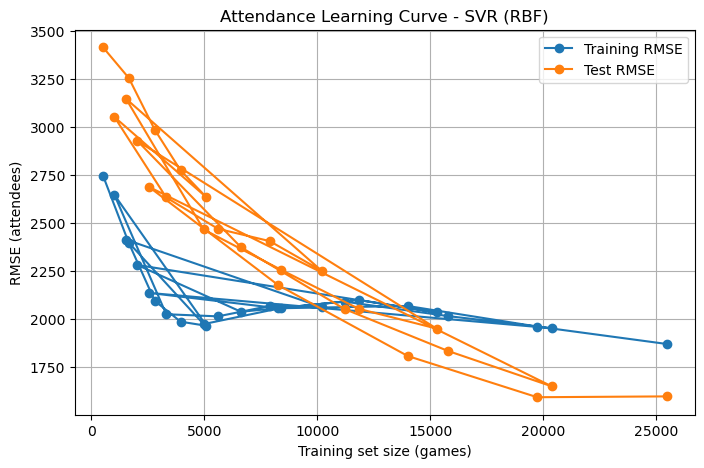

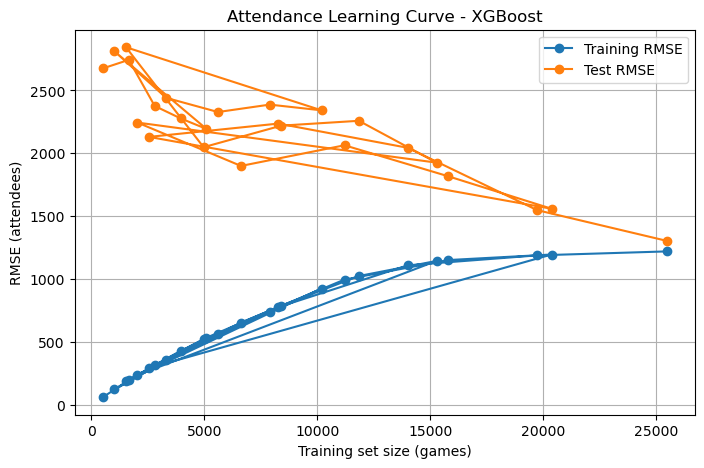

In [11]:
# Training sizes to test
train_sizes = np.linspace(0.1, 1.0, 5)

attendance_learning = {}

for name, make in [
    ("SVR (RBF)", make_svr),
    ("XGBoost", make_xgb_reg)
]:
    train_rmse = []
    test_rmse = []
    sizes_used = []

    # Use the time-based folds
    for fold, (tr, te) in enumerate(tscv.split(X_cv), start=1):

        fold_sizes = (train_sizes * len(tr)).astype(int)

        for size in fold_sizes:
            if size < 1:
                continue

            # Keep the training data in time order
            tr_use = tr[:size]

            model = make()

            # Train the model
            model.fit(X_cv.iloc[tr_use], y_cv.iloc[tr_use])

            # Predict training and test data
            train_pred = model.predict(X_cv.iloc[tr_use])
            test_pred = model.predict(X_cv.iloc[te])

            # Calculate RMSE
            train_score = np.sqrt(
                mean_squared_error(y_cv.iloc[tr_use], train_pred)
            )
            test_score = np.sqrt(
                mean_squared_error(y_cv.iloc[te], test_pred)
            )

            train_rmse.append(train_score)
            test_rmse.append(test_score)
            sizes_used.append(size)

    attendance_learning[name] = {
        "sizes": np.array(sizes_used),
        "train_rmse": np.array(train_rmse),
        "test_rmse": np.array(test_rmse)
    }

# Plot the attendance learning curves
for name, result in attendance_learning.items():
    plt.figure(figsize=(8, 5))

    plt.plot(
        result["sizes"],
        result["train_rmse"],
        marker="o",
        label="Training RMSE"
    )

    plt.plot(
        result["sizes"],
        result["test_rmse"],
        marker="o",
        label="Test RMSE"
    )

    plt.xlabel("Training set size (games)")
    plt.ylabel("RMSE (attendees)")
    plt.title(f"Attendance Learning Curve - {name}")
    plt.legend()
    plt.grid(True)
    fname = name.split(" ")[0].lower()
    plt.savefig(f"figures/lc_attendance_{fname}.png", dpi=200, bbox_inches="tight")
    plt.show()

In [12]:
att_lc = pd.DataFrame(attendance_learning["XGBoost"]).groupby("sizes").agg(["mean", "std"]).round(1)
display(att_lc)
att_lc.to_csv("outputs/lc_attendance_xgboost.csv")

train_rmse     test_rmse    
            mean std      mean std
sizes                             
509         61.5 NaN    2675.3 NaN
1018       123.3 NaN    2810.7 NaN
1527       188.4 NaN    2843.3 NaN
1654       198.8 NaN    2742.8 NaN
2036       236.9 NaN    2244.4 NaN
2545       293.2 NaN    2130.6 NaN
2800       316.8 NaN    2376.3 NaN
3309       358.1 NaN    2440.9 NaN
3945       429.8 NaN    2277.7 NaN
4963       524.7 NaN    2048.7 NaN
5091       530.0 NaN    2193.8 NaN
5600       567.8 NaN    2328.2 NaN
6618       655.1 NaN    1899.8 NaN
7891       738.7 NaN    2387.2 NaN
8272       777.3 NaN    2236.4 NaN
8400       789.0 NaN    2220.0 NaN
10182      925.4 NaN    2341.8 NaN
11200      996.4 NaN    2064.0 NaN
11836     1024.8 NaN    2258.6 NaN
14000     1110.0 NaN    2043.9 NaN
15273     1144.9 NaN    1926.1 NaN
15782     1151.6 NaN    1818.1 NaN
19727     1188.9 NaN    1548.4 NaN
20364     1195.8 NaN    1559.6 NaN
25455     1220.5 NaN    1304.7 NaN

The curves show how attendance prediction changes as the training size increases.
Training RMSE is calculated using the data used to train the model.
Test RMSE is calculated on later unseen data.
A smaller gap between the curves generally means the model is generalising better.
The time order is kept so that later data is not used to predict earlier data.

### 3.2 Churn

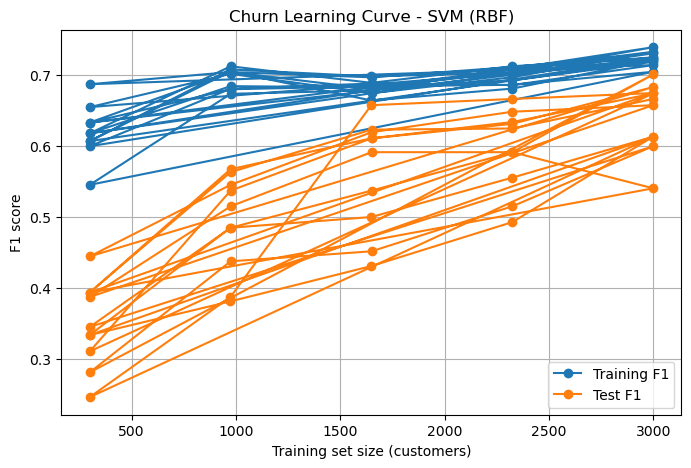

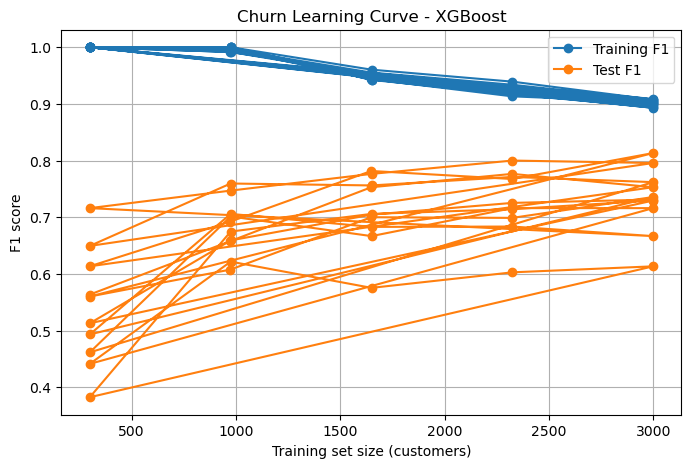

In [13]:
# Training sizes to test
train_sizes = np.linspace(0.1, 1.0, 5)

churn_learning = {}

for name, make in [
    ("SVM (RBF)", make_svc),
    ("XGBoost", make_xgb_clf)
]:
    train_f1 = []
    test_f1 = []
    sizes_used = []

    # Use the stratified folds
    for fold, (tr, te) in enumerate(skf.split(Xc, yc), start=1):

        fold_sizes = (train_sizes * len(tr)).astype(int)

        for size in fold_sizes:
            if size < 1:
                continue

            # Keep the training data from the fold
            tr_use = tr[:size]

            model = make()

            # Train the model
            model.fit(Xc.iloc[tr_use], yc.iloc[tr_use])

            # Predict training and test data
            train_pred = model.predict(Xc.iloc[tr_use])
            test_pred = model.predict(Xc.iloc[te])

            # Calculate F1
            train_score = f1_score(
                yc.iloc[tr_use],
                train_pred,
                zero_division=0
            )

            test_score = f1_score(
                yc.iloc[te],
                test_pred,
                zero_division=0
            )

            train_f1.append(train_score)
            test_f1.append(test_score)
            sizes_used.append(size)

    churn_learning[name] = {
        "sizes": np.array(sizes_used),
        "train_f1": np.array(train_f1),
        "test_f1": np.array(test_f1)
    }

# Plot the churn learning curves
for name, result in churn_learning.items():
    plt.figure(figsize=(8, 5))

    plt.plot(
        result["sizes"],
        result["train_f1"],
        marker="o",
        label="Training F1"
    )

    plt.plot(
        result["sizes"],
        result["test_f1"],
        marker="o",
        label="Test F1"
    )

    plt.xlabel("Training set size (customers)")
    plt.ylabel("F1 score")
    plt.title(f"Churn Learning Curve - {name}")
    plt.legend()
    plt.grid(True)
    fname = name.split(" ")[0].lower()
    plt.savefig(f"figures/lc_churn_{fname}.png", dpi=200, bbox_inches="tight")
    plt.show()

In [14]:
churn_lc = pd.DataFrame(churn_learning["XGBoost"]).groupby("sizes").agg(["mean", "std"]).round(3)
display(churn_lc)
churn_lc.to_csv("outputs/lc_churn_xgboost.csv")

train_f1        test_f1       
          mean    std    mean    std
sizes                               
299      1.000  0.000   0.579  0.030
300      1.000  0.000   0.522  0.119
974      0.995  0.002   0.653  0.043
975      0.998  0.003   0.696  0.048
1649     0.949  0.005   0.745  0.041
1650     0.950  0.007   0.695  0.066
2324     0.917  0.004   0.748  0.042
2325     0.927  0.008   0.716  0.063
2999     0.900  0.006   0.767  0.041
3000     0.902  0.005   0.716  0.060

The churn learning curves show how F1 changes when more training data is used.
Training F1 shows performance on the data used for training.
Test F1 shows performance on unseen data.
If test F1 improves with more data, the additional training data is helping.
A large difference between training and test F1 can indicate overfitting.
Stratified folds keep the churn and non-churn proportions more consistent between folds.

### 3.3 Notes for write-up
_Your observations here._

## 4. (c) Bias and fairness (Fairlearn)
**Brief:** What bias shows up in the data or models? Justify the tool choice.

### 4.1 Churn

In [15]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train the XGBoost churn model
# Get cross-validation predictions
yc_pred = cross_val_predict(
    make_xgb_clf(),
    Xc,
    yc,
    cv=skf,
    n_jobs=-1
)

# Create the groups
churn_groups = {
    "DataPlan": meta_churn["DataPlan"],
    "ServiceCalls_4plus": (meta_churn["CustServCalls"] >= 4).astype(int),
    "Tenure_quartile": pd.qcut(
        meta_churn["AccountWeeks"],
        q=4,
        labels=False
    )
}

# Check fairness for each group
for group_name, groups in churn_groups.items():

    print(f"\nChurn fairness: {group_name}")

    mf = MetricFrame(
        metrics={
            "accuracy": accuracy_score,
            "precision": lambda y, p: precision_score(
                y, p, zero_division=0
            ),
            "recall": lambda y, p: recall_score(
                y, p, zero_division=0
            ),
            "f1": lambda y, p: f1_score(
                y, p, zero_division=0
            ),
            "selection_rate": selection_rate
        },
        y_true=yc,
        y_pred=yc_pred,
        sensitive_features=groups
    )

    display(mf.by_group.round(3))

    print("group sizes:", dict(pd.Series(groups).value_counts().sort_index()))
    print("churn rate by group:", dict(pd.Series(yc).groupby(pd.Series(groups)).mean().round(3)))
    display(mf.difference().round(3))


Churn fairness: DataPlan


,accuracy,precision,recall,f1,selection_rate
DataPlan,,,,,
0,0.925,0.840,0.677,0.750,0.135
1,0.951,0.872,0.512,0.646,0.051


group sizes: {0: 2411, 1: 922}
churn rate by group: {0: 0.167, 1: 0.087}


accuracy          0.027
precision         0.032
recall            0.165
f1                0.104
selection_rate    0.084
dtype: float64


Churn fairness: ServiceCalls_4plus


...

accuracy          0.089
precision         0.050
recall            0.246
f1                0.169
selection_rate    0.408
dtype: float64


Churn fairness: Tenure_quartile


,accuracy,precision,recall,f1,selection_rate
AccountWeeks,,,,,
0,0.944,0.857,0.690,0.765,0.106
1,0.929,0.844,0.643,0.730,0.113
2,0.934,0.861,0.690,0.767,0.126
3,0.920,0.810,0.576,0.673,0.102


group sizes: {0: 857, 1: 847, 2: 803, 3: 826}
churn rate by group: {0: 0.132, 1: 0.149, 2: 0.157, 3: 0.143}


accuracy          0.024
precision         0.052
recall            0.114
f1                0.093
selection_rate    0.024
dtype: float64

### 4.2 Attendance

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use the held-out XGBoost predictions from Section 2.2
rows = attendance_predictions["row"].astype(int)

y_true_att = attendance_predictions["actual"].to_numpy()
y_pred_att = attendance_predictions["pred"].to_numpy()

# Get the matching group information
meta_fair = meta_cv.iloc[rows].copy()

# Create the groups
attendance_groups = {
    "MarketSize": pd.qcut(
        meta_fair["H Pop"],
        q=4,
        labels=False,
        duplicates="drop"
    ),
    "Era": pd.Series(
        (meta_fair["Time"] >= "2005-01-01").astype(int),
        index=meta_fair.index
    ),
    "AttendanceBand": pd.qcut(
        y_true_att,
        q=4,
        labels=False,
        duplicates="drop"
    )
}

# Check fairness for each group
for group_name, groups in attendance_groups.items():

    print(f"\nAttendance fairness: {group_name}")

    mf = MetricFrame(
        metrics={
            "MAE": mean_absolute_error,
            "RMSE": lambda y, p: np.sqrt(
                mean_squared_error(y, p)
            ),
            "MeanSignedError": lambda y, p: np.mean(p - y)
        },
        y_true=y_true_att,
        y_pred=y_pred_att,
        sensitive_features=groups
    )

    display(mf.by_group.round(3))

    print("Group sizes:")
    display(pd.Series(groups).value_counts().sort_index())

    print("Difference between largest and smallest group:")
    display(mf.difference().round(3))


Attendance fairness: MarketSize


,MAE,RMSE,MeanSignedError
H Pop,,,
0,1763.559,2327.752,-278.649
1,1359.472,1886.623,-463.815
2,1238.688,1751.690,-380.045
3,925.681,1361.993,-505.575


Group sizes:


H Pop
0    9264
1    5679
2    4765
3    5747
Name: count, dtype: int64

Difference between largest and smallest group:


...

,MAE,RMSE,MeanSignedError
sensitive_feature_0,,,
0,1893.119,2479.981,1328.055
1,1163.521,1569.725,-641.787
2,1118.938,1615.283,-950.072
3,1374.846,1961.830,-1310.115


Group sizes:


0    6364
1    6432
2    6469
3    6190
Name: count, dtype: int64

Difference between largest and smallest group:


MAE                 774.181
RMSE                910.256
MeanSignedError    2638.169
dtype: float64

### 4.3 Notes for write-up
_Your observations here. Report group sizes._

Fairlearn was used because it makes it easier to compare model performance between different groups.
For churn, I checked differences between DataPlan groups, customers with fewer or more than 4 customer service calls, and AccountWeeks quartiles.
For attendance, I checked groups based on H Pop, the pre/post-2005 era, and Attendance quartiles.
The group sizes are important because a very small group can make its results less stable.
Differences between groups do not automatically mean that the model is unfair. They can also reflect differences already present in the data.
The fairness results should therefore be considered together with the model performance and the characteristics of each group

## 5. (d) Security, privacy and ethical risks
This is a written section in the report. Keep research notes and sources here if useful.

_Notes:_

Privacy: The datasets contain information that could be sensitive, so data should be collected and used responsibly.
Australian privacy law: The Privacy Act 1988 and Australian Privacy Principles (APPs) are relevant when handling personal information.
Membership inference: An attacker may try to find out whether a particular person's data was included in a model's training data.
Data poisoning: Incorrect or deliberately changed training data could affect the model's results.
Targeted marketing: Churn predictions could potentially be used to target customers based on their predicted behaviour. This could raise ethical concerns if customers are not aware of how their data is being used.
Fairness: Differences in model performance between groups should be checked rather than assuming that the model treats everyone equally.
Data security: Access to datasets and model outputs should be controlled to reduce the risk of unauthorised use.

## 6. Export tables and figures for Overleaf
Save PNGs to `figures/` and tables to `outputs/`.

In [17]:
import os

# Create folders for the output files
os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [18]:
# Save the table
churn_summary.to_csv("outputs/churn_cv_results.csv", index=False)
attendance_summary.to_csv("outputs/attendance_cv_results.csv", index=False)